In [1]:
!pip install Sastrawi

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 209.7/209.7 kB 6.9 MB/s eta 0:00:00


In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

import re
import string

from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


***1. Data Understanding***

In [4]:
data_t = pd.read_csv('/content/drive/MyDrive/Sentiment analysis project/tweet.csv')
data_t.sample(10)

,Unnamed: 0,sentimen,tweet
612,612,negatif,wkwkwkk... uang gaji dari LN buat apa..?? samp...
1718,1718,netral,Prabowo-sandi sepakat tidak akan mengambil gaj...
1178,1178,positif,THE GREAT CLOSING STATEMENT FROM THE NEXT INDO...
497,497,negatif,Tetapi tetap tdk bisa kebijakan ekonomi nasion...
1623,1623,positif,Insyaallah Prabowo Sandi bisa. Mungkin ga kese...
45,45,negatif,#UAHUASUAHUAS ... Meskipun aku di surga Mungk...
1514,1514,netral,@prabowo gak tega nyalahin jokoei...krn rezim ...
1143,1143,positif,Lihat cuplikan debat semalam baru tau kalau pe...
286,286,positif,"Siapapun nnti presidennya, tolong program pert..."
458,458,netral,Jika Prabowo - Sandi Menang saya berjanji tida...


**Mengambil kolom tweet dan sentimen dan dijadikan dataset data_olah**




In [5]:
data_olah = data_t[['tweet','sentimen']]

In [6]:
from sklearn.model_selection import train_test_split

x_tweet = data_olah['tweet']
y_tweet = data_olah['sentimen']

x_train, x_test, y_train, y_test = train_test_split(
    x_tweet, y_tweet,
    test_size=0.2,
    random_state=42
)

In [ ]:
x_train.shape

(1452,)

In [7]:
data_olah.head()

,tweet,sentimen
0,Kata @prabowo Indonesia tidak dihargai bangsa ...,negatif
1,"Batuan Langka, Tasbih Jokowi Hadiah dari Habib...",netral
2,"Di era Jokowi, ekonomi Indonesia semakin baik....",netral
3,"Bagi Sumatera Selatan, Asian Games berdampak p...",positif
4,Negara kita ngutang buat bngun infrastruktur y...,negatif


In [ ]:
x_test.shape

(363,)

In [8]:
data_train = pd.DataFrame({'tweet': x_train, 'sentimen': y_train})
data_train.head()

,tweet,sentimen
609,Komentarnya bagus. Tapi alangkah indshnya jika...,positif
844,Jokowi: Pertumbuhan Ekonomi >5% Harus Disyukur...,netral
300,"Buat yang ciwi-ciwi, mau harga skincare turun?...",netral
1702,"Alhamdulillah,penutup terkeren dr @prabowo Da...",positif
614,"Pun dari hal yang diutarakan Jokowi kemaren, e...",netral


In [9]:
data_test = pd.DataFrame({'tweet': x_test, 'sentimen': y_test})
data_test.head()

,tweet,sentimen
567,"Bukan hanya kurang milenial, tapi memang dia s...",negatif
432,artinya presiden yg ke 6 tdk menerima gaji.pra...,positif
1750,Kalau menurut saya bang @sandiuno dan bapak ...,positif
674,Bukan hanya ekonomi aja Pak....namun kehidupan...,negatif
111,"Gak ngaruh, jokowi mau ke kutub utara juga, ra...",negatif


In [ ]:
data_test['sentimen'].value_counts()

,count
sentimen,
positif,130
netral,118
negatif,115


**Cek adakah kosong dan duplikat**

In [ ]:
data_olah.duplicated().sum()

np.int64(0)

In [ ]:
data_olah.isnull().sum()

,0
tweet,0
sentimen,0


**Visualisasi Distribusi Label**

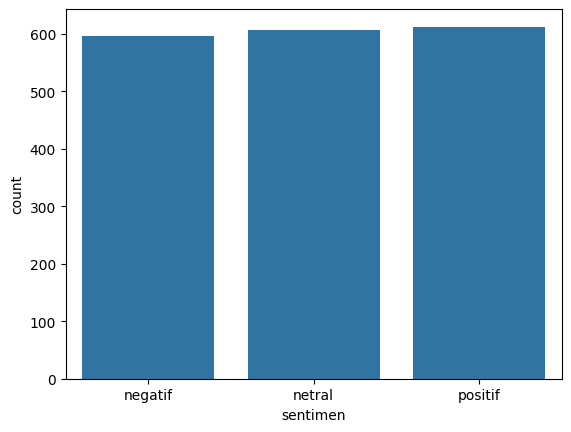

In [10]:
sns.countplot(x='sentimen', data=data_olah)
plt.show()

***2. TEXT PROCESSING***

Rencana yang akan dilakukan adalah

```
1 Lowercase
2 Remove URL
3 Remove Mention
4 Remove Hashtag
5 Remove punctuation
6 Remove number
7 Remove weird character
8 Normalisasi
9 Negasi
10 Remove stopwords
11 Stemming
```



In [11]:
#Inisialisasi Stemmer dan Stopword

factory = StemmerFactory()
stemmer = factory.create_stemmer()

stop_factory = StopWordRemoverFactory()
stopwords = stop_factory.get_stop_words()

In [12]:
#function cleaning Text

def clean_text_dummy(text):

    text = text.lower()

    # remove url
    text = re.sub(r'http\S+', '', text)

    # remove mention
    text = re.sub(r'@(\w+)', r'\1', text)

    # remove hashtag
    text = re.sub(r'#(\w+)', r'\1', text)

    # remove number
    text = re.sub(r'\d+', '', text)

    # remove punctuation
    text = text.translate(str.maketrans('', '', string.punctuation))

    # remove extra whitespace
    text = text.strip()

    return text

In [13]:
# Proses cleaning
data_train['clean_tweet'] = data_train['tweet'].apply(clean_text_dummy)

In [14]:
data_train

,tweet,sentimen,clean_tweet
609,Komentarnya bagus. Tapi alangkah indshnya jika...,positif,komentarnya bagus tapi alangkah indshnya jika ...
844,Jokowi: Pertumbuhan Ekonomi >5% Harus Disyukur...,netral,jokowi pertumbuhan ekonomi harus disyukuri ja...
300,"Buat yang ciwi-ciwi, mau harga skincare turun?...",netral,buat yang ciwiciwi mau harga skincare turun tu...
1702,"Alhamdulillah,penutup terkeren dr @prabowo Da...",positif,alhamdulillahpenutup terkeren dr prabowo dan ...
614,"Pun dari hal yang diutarakan Jokowi kemaren, e...",netral,pun dari hal yang diutarakan jokowi kemaren es...
...,...,...,...
1130,Jelas salah pemerintah yg membuat hukumnya ga ...,negatif,jelas salah pemerintah yg membuat hukumnya ga ...
1294,Yg dikatakan Pak @prabowo itu benar. Kita semu...,positif,yg dikatakan pak prabowo itu benar kita semua ...
860,"Namanya juga jaman modern, gaji ya ditransfer ...",netral,namanya juga jaman modern gaji ya ditransfer b...
1459,"Alhamdulillah,smoga terlaksana cita2 #prabowos...",positif,alhamdulillahsmoga terlaksana cita prabowosand...


In [15]:
# Function Normalisasi
def normalize_text(text):

    words = text.split()

    normalized = [normalisasi[word] if word in normalisasi else word for word in words]

    return " ".join(normalized)

In [16]:
normalisasi = {
    "yg": "yang",
    "dgn": "dengan",
    "dg": "dengan",
    "tdk": "tidak",
    "gk": "tidak",
    "ga": "tidak",
    "nggak": "tidak",
    "tak": "tidak",
    "bkn": "bukan",
    "krn": "karena",
    "dr": "dari",
    "dlm": "dalam",
    "pd": "pada",
    "utk": "untuk",
    "jd": "jadi",
    "jg": "juga",
    "sm": "sama",
    "sama2": "sama sama",
    "sy": "saya",
    "sya": "saya",
    "gw": "saya",
    "gue": "saya",
    "aku": "saya",
    "km": "kamu",
    "kmu": "kamu",
    "loe": "kamu",
    "lu": "kamu",
    "org": "orang",
    "byk": "banyak",
    "bnyk": "banyak",
    "sdh": "sudah",
    "udh": "sudah",
    "blm": "belum",
    "hrs": "harus",
    "hrus": "harus",
    "bs": "bisa",
    "bsa": "bisa",
    "aja": "saja",
    "doang": "saja",
    "tok": "saja",
    "nih": "ini",
    "ni": "ini",
    "ituu": "itu",
    "bgt": "banget",
    "bgtt": "banget",
    "amat": "sangat",
    "sangattt": "sangat",
    "tp": "tapi",
    "tpi": "tapi",
    "knp": "kenapa",
    "kpn": "kapan",
    "gmn": "bagaimana",
    "gmna": "bagaimana",
    "mn": "mana",
    "drmn": "darimana",
    "dimn": "dimana",
    "kmn": "kemana",
    "pgn": "ingin",
    "pngen": "ingin",
    "mau": "ingin",
    "trs": "terus",
    "trus": "terus",
    "udh": "sudah",
    "lg": "lagi",
    "lgi": "lagi",
    "skrg": "sekarang",
    "skrng": "sekarang",
    "dpt": "dapat",
    "dapet": "dapat",
    "ngasih": "memberi",
    "ngasi": "memberi",
    "ngambil": "mengambil",
    "ngaku": "mengaku",
    "ngomong": "berbicara",
    "ngeliat": "melihat",
    "ngerti": "mengerti",
    "pke": "pakai",
    "pkai": "pakai",
    "pakaii": "pakai",
    "krja": "kerja",
    "kerja2": "kerja kerja",
    "rkyat": "rakyat",
    "indo": "indonesia",
    "ind": "indonesia",
    "negri": "negeri",
    "pemrintah": "pemerintah",
    "presidenya": "presidennya",
    "pemimpin2": "pemimpin pemimpin"
}

In [17]:
# Menjalankan normalisasi
data_train['clean_tweet'] = data_train['clean_tweet'].apply(normalize_text)

In [18]:
data_train

,tweet,sentimen,clean_tweet
609,Komentarnya bagus. Tapi alangkah indshnya jika...,positif,komentarnya bagus tapi alangkah indshnya jika ...
844,Jokowi: Pertumbuhan Ekonomi >5% Harus Disyukur...,netral,jokowi pertumbuhan ekonomi harus disyukuri jan...
300,"Buat yang ciwi-ciwi, mau harga skincare turun?...",netral,buat yang ciwiciwi ingin harga skincare turun ...
1702,"Alhamdulillah,penutup terkeren dr @prabowo Da...",positif,alhamdulillahpenutup terkeren dari prabowo dan...
614,"Pun dari hal yang diutarakan Jokowi kemaren, e...",netral,pun dari hal yang diutarakan jokowi kemaren es...
...,...,...,...
1130,Jelas salah pemerintah yg membuat hukumnya ga ...,negatif,jelas salah pemerintah yang membuat hukumnya t...
1294,Yg dikatakan Pak @prabowo itu benar. Kita semu...,positif,yang dikatakan pak prabowo itu benar kita semu...
860,"Namanya juga jaman modern, gaji ya ditransfer ...",netral,namanya juga jaman modern gaji ya ditransfer b...
1459,"Alhamdulillah,smoga terlaksana cita2 #prabowos...",positif,alhamdulillahsmoga terlaksana cita prabowosand...


In [19]:
# Function Menghilangkan Stopword
# =============================
# 1. Daftar kata negasi
# =============================

negasi = [
    "tidak","bukan","tak","kurang","tdk",
    "gak","ga","gk","nggak","ngga","enggak",
    "belum","jangan"
]


# =============================
# 2. Ambil stopword dari Sastrawi
# =============================

from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory

factory = StopWordRemoverFactory()
stopwords = factory.get_stop_words()


# =============================
# 3. Pastikan negasi tidak ada di stopword
# =============================

stopwords = set(stopwords) - set(negasi)


# =============================
# 4. Function Menghilangkan Stopword
# =============================

def remove_stopwords(text):

    # menghindari error jika text kosong
    if not isinstance(text, str):
        return ""

    words = text.split()

    filtered = [word for word in words if word not in stopwords]

    return " ".join(filtered)

In [20]:
# menjalankan menghilangkan stopword
data_train['clean_tweet'] = data_train['clean_tweet'].apply(remove_stopwords)

In [ ]:
data_train

,tweet,sentimen,clean_tweet
609,Komentarnya bagus. Tapi alangkah indshnya jika...,positif,komentarnya bagus alangkah indshnya ibu bilang...
844,Jokowi: Pertumbuhan Ekonomi >5% Harus Disyukur...,netral,jokowi pertumbuhan ekonomi disyukuri jangan ku...
300,"Buat yang ciwi-ciwi, mau harga skincare turun?...",netral,buat ciwiciwi harga skincare turun tusuk prabo...
1702,"Alhamdulillah,penutup terkeren dr @prabowo Da...",positif,alhamdulillahpenutup terkeren prabowo sandiuno...
614,"Pun dari hal yang diutarakan Jokowi kemaren, e...",netral,diutarakan jokowi kemaren esports sendiri mema...
...,...,...,...
1130,Jelas salah pemerintah yg membuat hukumnya ga ...,negatif,jelas salah pemerintah membuat hukumnya tidak ...
1294,Yg dikatakan Pak @prabowo itu benar. Kita semu...,positif,dikatakan pak prabowo benar semua bertanggung ...
860,"Namanya juga jaman modern, gaji ya ditransfer ...",netral,namanya jaman modern gaji ditransfer bukan dia...
1459,"Alhamdulillah,smoga terlaksana cita2 #prabowos...",positif,alhamdulillahsmoga terlaksana cita prabowosand...


In [21]:
# Function Stemming
def stemming(text):

    return stemmer.stem(text)

In [22]:
#menjalankan Stemmming
data_train['clean_tweet'] = data_train['clean_tweet'].apply(stemming)

In [ ]:
data_train[['tweet','clean_tweet','sentimen']].sample(5)

,tweet,clean_tweet,sentimen
68,Berita terbaru (Prabowo: Saya Tak Ingin Naikka...,berita baru prabowo tidak naik pajak persen ta...,netral
1402,"Kalau Terpilih, Prabowo-Sandi Tidak akan Perna...",kalau pilih prabowosandi tidak pernah ambil ga...,netral
469,Kalau lihat total program pasti tahu kualitas....,kalau lihat total program tahu kualitas bahas ...,negatif
1431,Denger tuh pak jae..nanti gaji dari pak Prabow...,denger tuh pak jaenanti gaji pak prabowo sandi...,negatif
77,Katanya Jas itu harga mahal dan pakaian orang2...,kata jas harga mahal pakai orang eropa amerika,netral


In [23]:
#negasi
negasi = [
    "tidak","bukan","gak","ga","nggak","tak","kurang","tdk","enggak","gk","ngga","nda","ndak","jangan","belum"
]

In [24]:
#function Negasi Handling

def handle_negation(text):
    negasi = ["tidak","bukan","gak","ga","nggak","tak","kurang","tdk","enggak","gk","ngga","nda","ndak","jangan","belum"]

    words = text.split()
    result = []
    skip = False

    for i in range(len(words)):
        if skip:
            skip = False
            continue

        if words[i] in negasi and i+1 < len(words):
            result.append(words[i] + "_" + words[i+1])
            skip = True
        else:
            result.append(words[i])

    return " ".join(result)

In [25]:
# menjalankan menghilangkan Negasi
data_train['clean_tweet'] = data_train['clean_tweet'].apply(handle_negation)

In [ ]:
data_train

,tweet,sentimen,clean_tweet
609,Komentarnya bagus. Tapi alangkah indshnya jika...,positif,komentar bagus alangkah indshnya ibu bilang jo...
844,Jokowi: Pertumbuhan Ekonomi >5% Harus Disyukur...,netral,jokowi tumbuh ekonomi syukur jangan_kufur nikm...
300,"Buat yang ciwi-ciwi, mau harga skincare turun?...",netral,buat ciwiciwi harga skincare turun tusuk prabo...
1702,"Alhamdulillah,penutup terkeren dr @prabowo Da...",positif,alhamdulillahpenutup keren prabowo sandiuno ti...
614,"Pun dari hal yang diutarakan Jokowi kemaren, e...",netral,utara jokowi kemaren esports sendiri memang be...
...,...,...,...
1130,Jelas salah pemerintah yg membuat hukumnya ga ...,negatif,jelas salah perintah buat hukum tidak_ketat co...
1294,Yg dikatakan Pak @prabowo itu benar. Kita semu...,positif,kata pak prabowo benar semua tanggung jawab ul...
860,"Namanya juga jaman modern, gaji ya ditransfer ...",netral,nama jaman modern gaji transfer bukan_ambil pi...
1459,"Alhamdulillah,smoga terlaksana cita2 #prabowos...",positif,alhamdulillahsmoga laksana cita prabowosandiaa...


***Preprocessing data Testing***

In [26]:
# Proses cleaning
data_test['clean_tweet'] = data_test['tweet'].apply(clean_text_dummy)

# Menjalankan normalisasi
data_test['clean_tweet'] = data_test['clean_tweet'].apply(normalize_text)

# menjalankan menghilangkan stopword
data_test['clean_tweet'] = data_test['clean_tweet'].apply(remove_stopwords)

#menjalankan Stemmming
data_test['clean_tweet'] = data_test['clean_tweet'].apply(stemming)

# menjalankan menghilangkan Negasi
data_test['clean_tweet'] = data_test['clean_tweet'].apply(handle_negation)

In [ ]:
data_test

,tweet,sentimen,clean_tweet
567,"Bukan hanya kurang milenial, tapi memang dia s...",negatif,bukan_kurang milenial memang sama sekali tidak...
432,artinya presiden yg ke 6 tdk menerima gaji.pra...,positif,arti presiden tidak_terima gajiprabowo sandi l...
1750,Kalau menurut saya bang @sandiuno dan bapak ...,positif,kalau bang sandiuno bapak prabowo mampu tempat...
674,Bukan hanya ekonomi aja Pak....namun kehidupan...,negatif,bukan_ekonomi paknamun hidup buruh korbanphkil...
111,"Gak ngaruh, jokowi mau ke kutub utara juga, ra...",negatif,gak_ngaruh jokowi kutub utara rakyat tau baran...
...,...,...,...
1125,FYI: Digital ekonomi yang di paparkan oleh caw...,positif,fyi digital ekonomi papar cawapres laku era pe...
1142,"Jelas : "" Prabowo dalam debat kelima menyebut ...",netral,jelas prabowo debat lima sebut soal ekonomi de...
1512,gaji prabowo-sandi bakal buat kaum yatim & dhu...,positif,gaji prabowosandi bakal buat kaum yatim dhuafa...
170,@jokowi @mohmahfudmd @SBYudhoyono @setkabgoid ...,netral,jokowi mohmahfudmd sbyudhoyono setkabgoid sala...


**LSTM**

***Melakukan encoding untuk data sentimen***

```
negatif = 0
netral = 1
positif = 2
```


In [27]:
from sklearn.preprocessing import LabelEncoder

In [28]:
encoder = LabelEncoder()

y_train = data_train['sentimen']
y_train_encode = encoder.fit_transform(y_train)

y_test = data_test['sentimen']
y_test_encode = encoder.transform(y_test)

In [ ]:
y_test_encode

array([0, 2, 2, 0, 0, 1, 1, 1, 1, 0, 2, 2, 0, 1, 0, 2, 0, 0, 1, 2, 0, 0,
       0, 1, 1, 2, 1, 1, 0, 0, 0, 2, 0, 0, 1, 0, 0, 2, 2, 1, 0, 2, 1, 1,
       2, 0, 2, 2, 2, 1, 2, 2, 1, 2, 0, 0, 1, 2, 0, 2, 2, 0, 0, 2, 2, 2,
       2, 0, 0, 1, 0, 0, 2, 2, 1, 2, 0, 2, 0, 1, 2, 1, 2, 2, 0, 2, 1, 2,
       2, 1, 0, 0, 1, 1, 1, 0, 0, 0, 2, 0, 1, 0, 2, 1, 2, 2, 2, 2, 1, 0,
       1, 2, 2, 1, 0, 0, 2, 1, 0, 0, 2, 0, 2, 1, 0, 1, 1, 2, 2, 2, 0, 2,
       2, 0, 2, 2, 1, 0, 1, 1, 2, 2, 1, 2, 1, 1, 1, 2, 1, 2, 0, 1, 2, 0,
       1, 1, 2, 2, 0, 1, 1, 2, 0, 0, 1, 0, 1, 1, 2, 1, 0, 1, 2, 1, 2, 2,
       0, 2, 2, 2, 2, 1, 2, 0, 1, 1, 2, 1, 1, 0, 1, 0, 1, 1, 1, 2, 2, 0,
       1, 0, 1, 2, 1, 0, 2, 0, 2, 1, 0, 1, 0, 1, 0, 1, 2, 1, 0, 2, 2, 1,
       2, 2, 0, 2, 2, 0, 1, 2, 0, 1, 0, 1, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0,
       1, 1, 2, 2, 2, 2, 2, 1, 2, 2, 2, 1, 1, 2, 0, 0, 0, 0, 2, 2, 1, 2,
       2, 1, 2, 0, 2, 0, 2, 2, 1, 1, 0, 0, 2, 1, 1, 2, 1, 0, 0, 0, 1, 2,
       1, 2, 0, 0, 1, 0, 0, 2, 2, 1, 1, 0, 1, 0, 2,

**Tokenization**

In [31]:
from tensorflow.keras.preprocessing.text import Tokenizer

tokenizer = Tokenizer(num_words=5000)
tokenizer.fit_on_texts(data_train["clean_tweet"])

x_train_seq = tokenizer.texts_to_sequences(data_train["clean_tweet"])
x_test_seq = tokenizer.texts_to_sequences(data_test["clean_tweet"])

**Padding**

In [32]:
from tensorflow.keras.preprocessing.sequence import pad_sequences

max_len = 50
x_train_pad = pad_sequences(x_train_seq, maxlen=max_len)
x_test_pad = pad_sequences(x_test_seq, maxlen=max_len)

Build and Train **LSTM**

In [33]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout

vocab_size = 5000
max_len = 50

lstm_model = Sequential([
    Embedding(input_dim=vocab_size, output_dim=128, input_length=max_len),
    LSTM(128, return_sequences=False),
    Dropout(0.5),
    Dense(64, activation='relu'),
    Dense(3, activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


**compile model**

In [34]:
from tensorflow.keras.optimizers import AdamW

lstm_model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer=AdamW(learning_rate=0.001),
    metrics=['accuracy']
)

lstm_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

**Training Model**

In [35]:
history = lstm_model.fit(
    x_train_pad,
    y_train_encode,
    epochs=15,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/15
37/37 ━━━━━━━━━━━━━━━━━━━━ 10s 150ms/step - accuracy: 0.4212 - loss: 1.0767 - val_accuracy: 0.4570 - val_loss: 1.0299
Epoch 2/15
37/37 ━━━━━━━━━━━━━━━━━━━━ 4s 102ms/step - accuracy: 0.5366 - loss: 0.9565 - val_accuracy: 0.5773 - val_loss: 0.9072
Epoch 3/15
37/37 ━━━━━━━━━━━━━━━━━━━━ 4s 97ms/step - accuracy: 0.7683 - loss: 0.6278 - val_accuracy: 0.6082 - val_loss: 0.8854
Epoch 4/15
37/37 ━━━━━━━━━━━━━━━━━━━━ 6s 165ms/step - accuracy: 0.8984 - loss: 0.3078 - val_accuracy: 0.6048 - val_loss: 1.1065
Epoch 5/15
37/37 ━━━━━━━━━━━━━━━━━━━━ 4s 103ms/step - accuracy: 0.9535 - loss: 0.1602 - val_accuracy: 0.5945 - val_loss: 1.2486
Epoch 6/15
37/37 ━━━━━━━━━━━━━━━━━━━━ 4s 102ms/step - accuracy: 0.9699 - loss: 0.0966 - val_accuracy: 0.6014 - val_loss: 1.5028
Epoch 7/15
37/37 ━━━━━━━━━━━━━━━━━━━━ 5s 142ms/step - accuracy: 0.9802 - loss: 0.0760 - val_accuracy: 0.5773 - val_loss: 1.5957
Epoch 8/15
37/37 ━━━━━━━━━━━━━━━━━━━━ 5s 125ms/step - accuracy: 0.9854 - loss: 0.0519 - val_accuracy: 0.

**Evaluasi Model**

In [36]:
# Prediksi
import numpy as np
y_pred_prob = lstm_model.predict(x_test_pad)
y_pred = np.argmax(y_pred_prob, axis=1)

12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 43ms/step


              precision    recall  f1-score   support

           0       0.60      0.57      0.59       115
           1       0.57      0.53      0.55       118
           2       0.51      0.57      0.54       130

    accuracy                           0.56       363
   macro avg       0.56      0.56      0.56       363
weighted avg       0.56      0.56      0.56       363



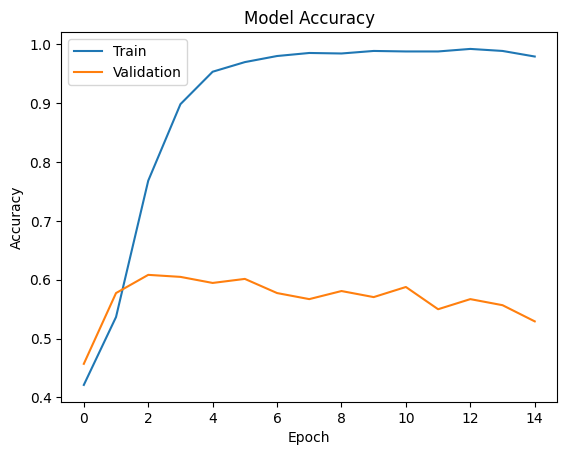

In [37]:
# Evaluation
from sklearn.metrics import classification_report, confusion_matrix
print(classification_report(y_test_encode, y_pred))
confusion_matrix(y_test_encode, y_pred)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train','Validation'])
plt.show()